In [16]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/mppun/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first 5 rows
print(df.head())

# Dataset Information
print(df.info())

# Shape
print("Shape:", df.shape)

# Column Names
print(df.columns)

# Statistical Summary
print(df.describe())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [17]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [19]:
df = df.drop_duplicates()

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1             80                

In [21]:
df.to_csv("Processed_Employee_Data.csv", index=False)

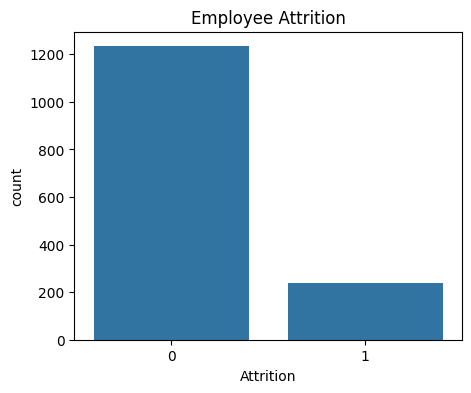

In [22]:
plt.figure(figsize=(5,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition")
plt.show()

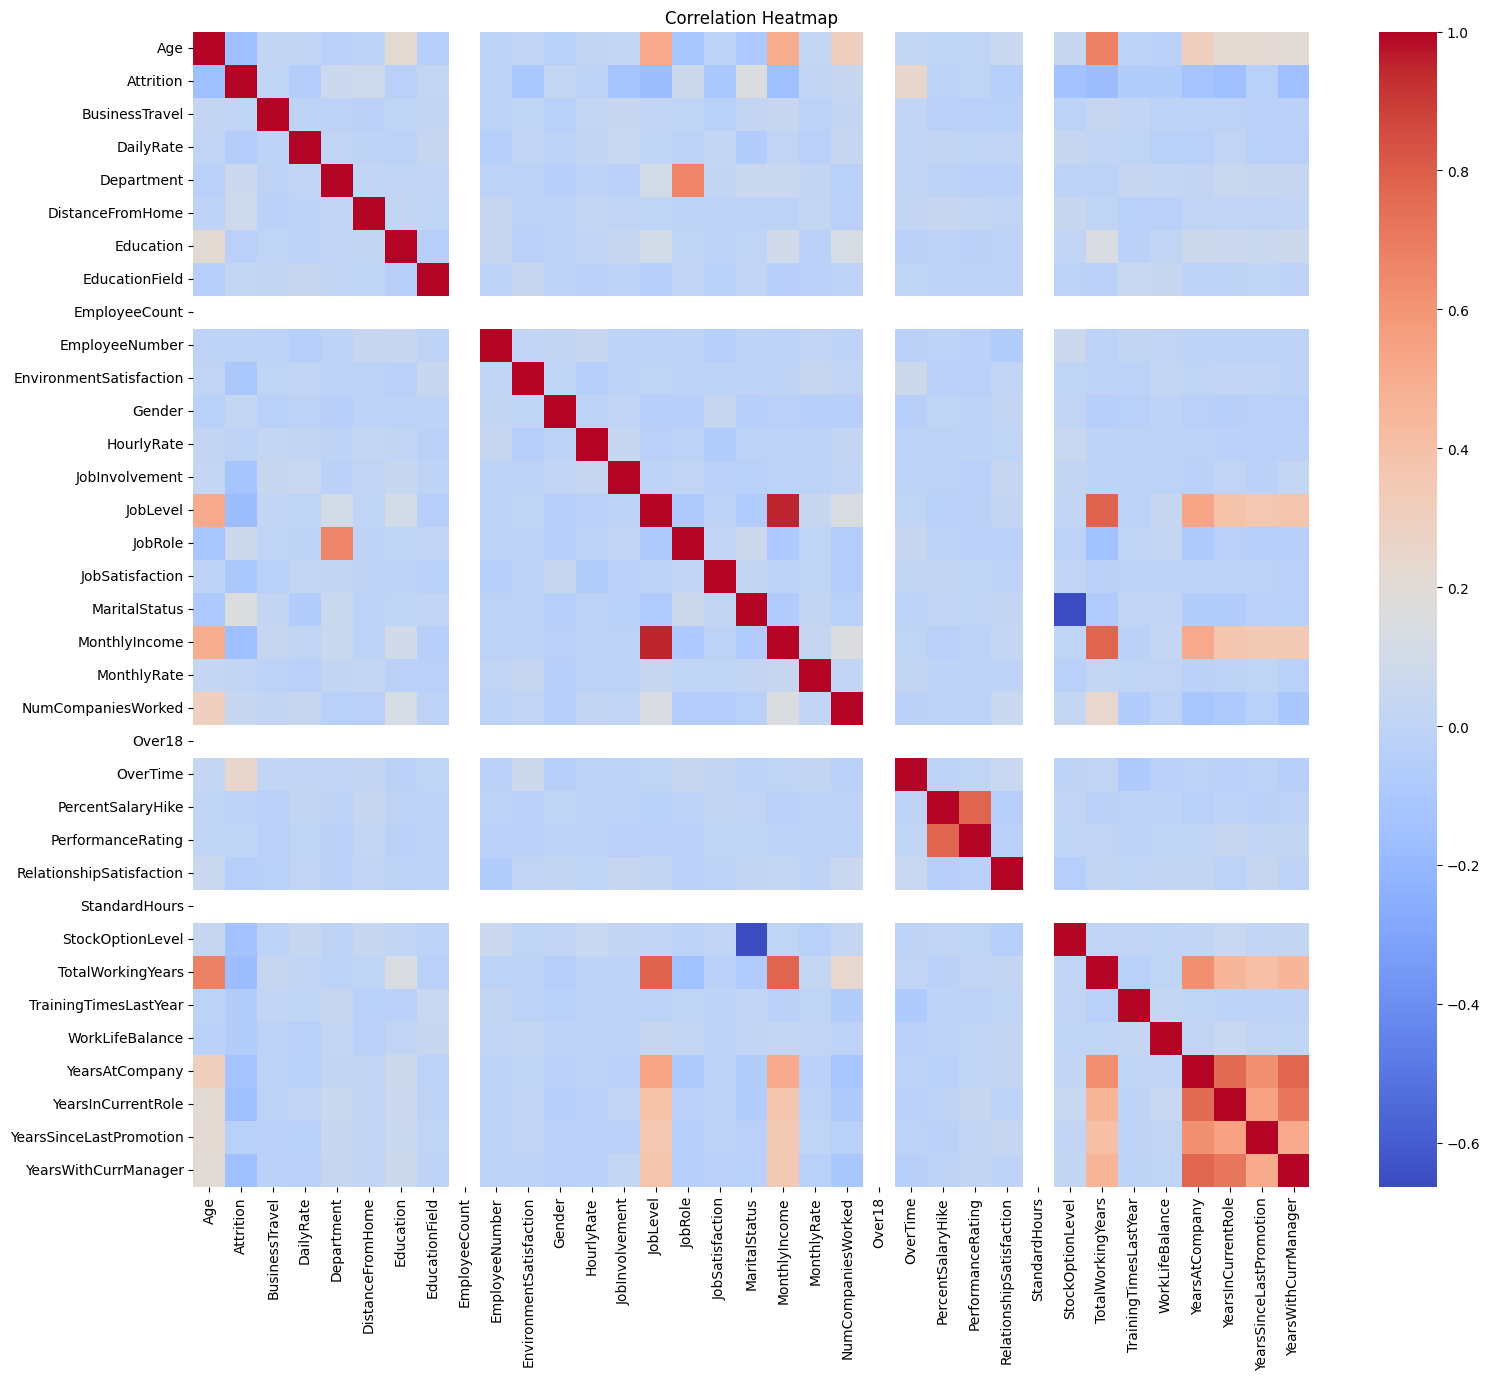

In [23]:
plt.figure(figsize=(18,15))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

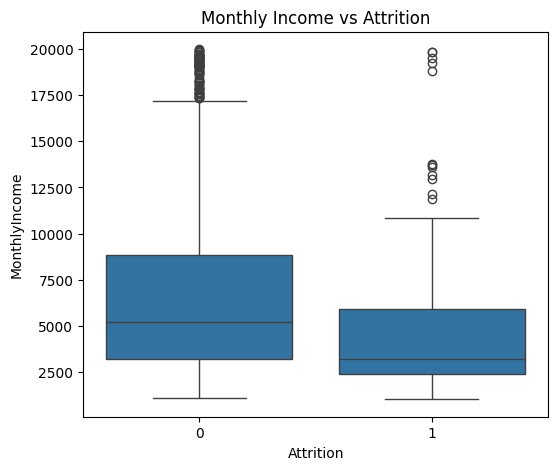

In [24]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

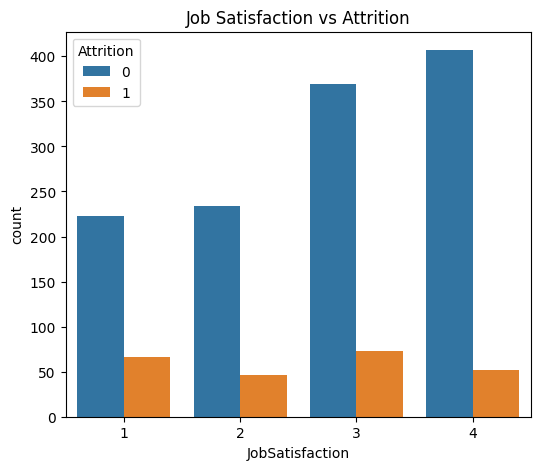

In [25]:
plt.figure(figsize=(6,5))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

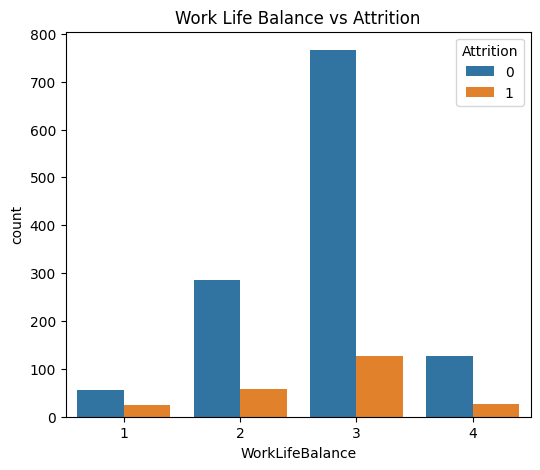

In [26]:
plt.figure(figsize=(6,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title("Work Life Balance vs Attrition")
plt.show()

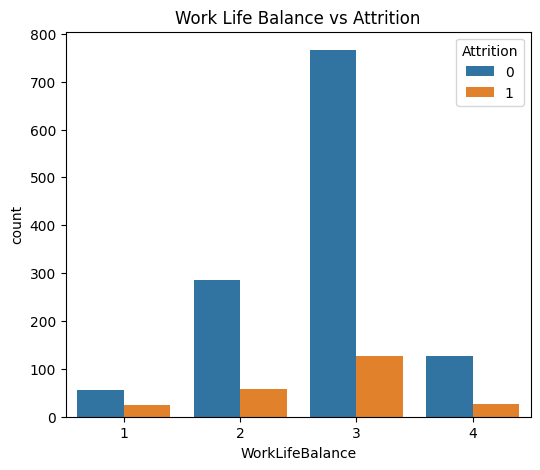

In [27]:
plt.figure(figsize=(6,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title("Work Life Balance vs Attrition")
plt.show()

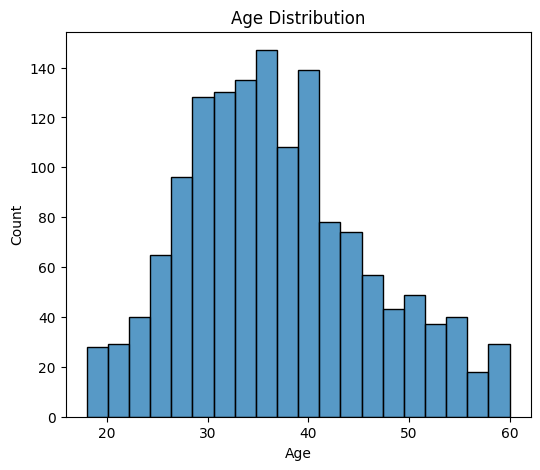

In [28]:
plt.figure(figsize=(6,5))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8673469387755102


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[251   4]
 [ 35   4]]


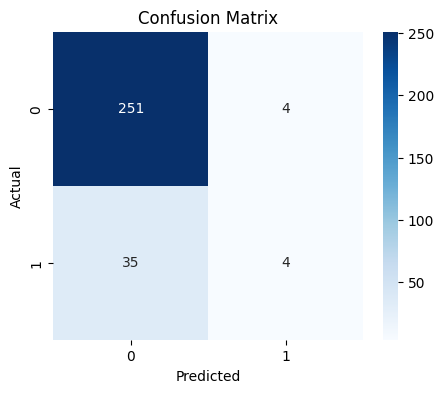

In [34]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [38]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

              Feature  Importance
17      MonthlyIncome    0.074968
21           OverTime    0.064823
0                 Age    0.056865
2           DailyRate    0.050505
27  TotalWorkingYears    0.048104
18        MonthlyRate    0.047090
8      EmployeeNumber    0.045296
11         HourlyRate    0.043352
4    DistanceFromHome    0.042012
30     YearsAtCompany    0.041914


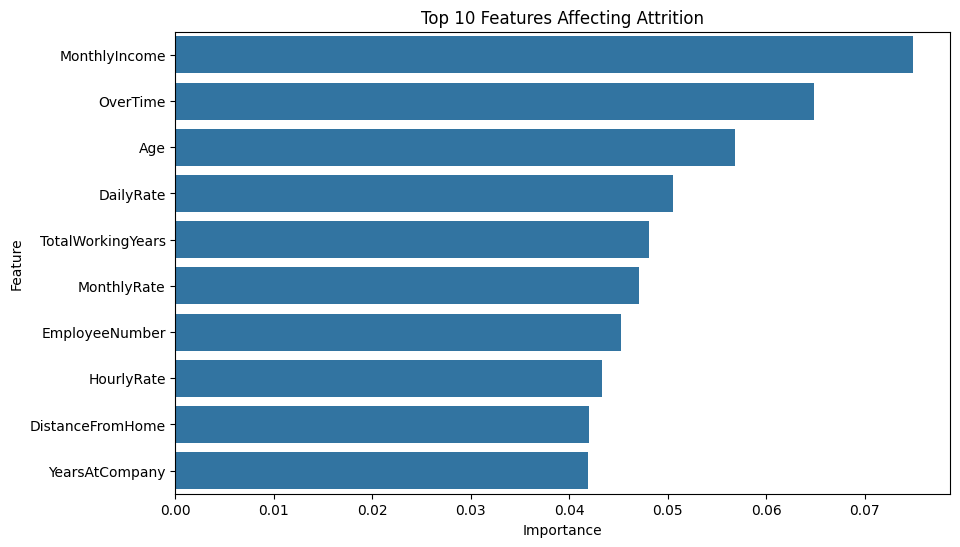

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Features Affecting Attrition")

plt.show()

In [40]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Employee is likely to Leave")
else:
    print("Employee is likely to Stay")

Prediction: [0]
Employee is likely to Stay


In [41]:
print("\n========== Employee Retention Insights ==========\n")

print("1. Employees with low Job Satisfaction are more likely to resign.")
print("2. Employees who work overtime have a higher attrition rate.")
print("3. Lower Monthly Income is associated with higher employee turnover.")
print("4. Younger employees are more likely to leave the organization.")
print("5. Poor Work-Life Balance contributes to employee attrition.")
print("6. Employees with fewer years at the company are more likely to resign.")
print("7. Improving employee satisfaction, salary, and work-life balance can reduce attrition.")


========== Employee Retention Insights ==========

1. Employees with low Job Satisfaction are more likely to resign.
2. Employees who work overtime have a higher attrition rate.
3. Lower Monthly Income is associated with higher employee turnover.
4. Younger employees are more likely to leave the organization.
5. Poor Work-Life Balance contributes to employee attrition.
6. Employees with fewer years at the company are more likely to resign.
7. Improving employee satisfaction, salary, and work-life balance can reduce attrition.
